# Load packages and libraries

In [1]:
.libPaths()
.libPaths(new = c("/home/manuel.tardaguila/conda_envs/multiome_QC/lib/R/library"))
.libPaths()
# sessionInfo()

Sys.setenv(RETICULATE_PYTHON="/home/manuel.tardaguila/conda_envs/multiome_QC/bin/python")
library(reticulate)
reticulate::use_python("/home/manuel.tardaguila/conda_envs/multiome_QC/bin/python")
reticulate::use_condaenv("/home/manuel.tardaguila/conda_envs/multiome_QC")
reticulate::py_module_available(module='leidenalg')
reticulate::import('leidenalg')
suppressMessages(library("optparse"))
suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))
suppressMessages(library(ggplot2))
suppressMessages(library(scDblFinder))
suppressMessages(library("tidyr"))
suppressMessages(library("tibble"))
suppressMessages(library("biovizBase"))
suppressMessages(library("patchwork"))
suppressMessages(library(glmGamPoi))
suppressMessages(library(SeuratData))
suppressMessages(library(SeuratDisk))
library(svglite)
library(RColorBrewer)




[1] "/home/manuel.tardaguila/R/x86_64-conda-linux-gnu-library/4.3"
[2] "/home/manuel.tardaguila/conda_envs/multiome_QC/lib/R/library"

[1] "/home/manuel.tardaguila/conda_envs/multiome_QC/lib/R/library"

[1] TRUE

Module(leidenalg)

Warning message:
“package ‘Seurat’ was built under R version 4.3.2”
Warning message:
“package ‘Signac’ was built under R version 4.3.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Warning message:
“package ‘IRanges’ was built under R version 4.3.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘Biobase’ was built under R version 4.3.2”
Warning message:
"package 'scDblFinder' was built under R version 4.3.2"
Warning message:
"package 'SingleCellExperiment' was built under R version 4.3.2"
Warning message:
"package 'SummarizedExperiment' was built under R version 4.3.2"
Warning message:
"package 'MatrixGenerics' was built under R version 4.3.2"
Warning message:
"package 'patchwork' was built under R version 4.3.3"
Warning message:
"package 'glmGamPoi' was built 

In [2]:
#AvailableData()

# Read objects already clustered not integrated

In [3]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-readRDS(file="merged_unprocessed_db_filt_clustered_minus_26_MACS2_peaks_HARMONY_clustered.rds")

In [4]:
adata

An object of class Seurat 
445320 features across 37504 samples within 4 assays 
Active assay: SCT (31512 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, RNA_raw, ATAC
 7 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, umap.wnn, harmony.rna, harmony.atac

In [ ]:
### Modality WNN at 1 resolution

adata <- FindClusters(adata, graph.name='wsnn', algorithm=4, resolution = 0.25, verbose=FALSE, method = "igraph")

In [4]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/graphs_FINAL_HARMONY"

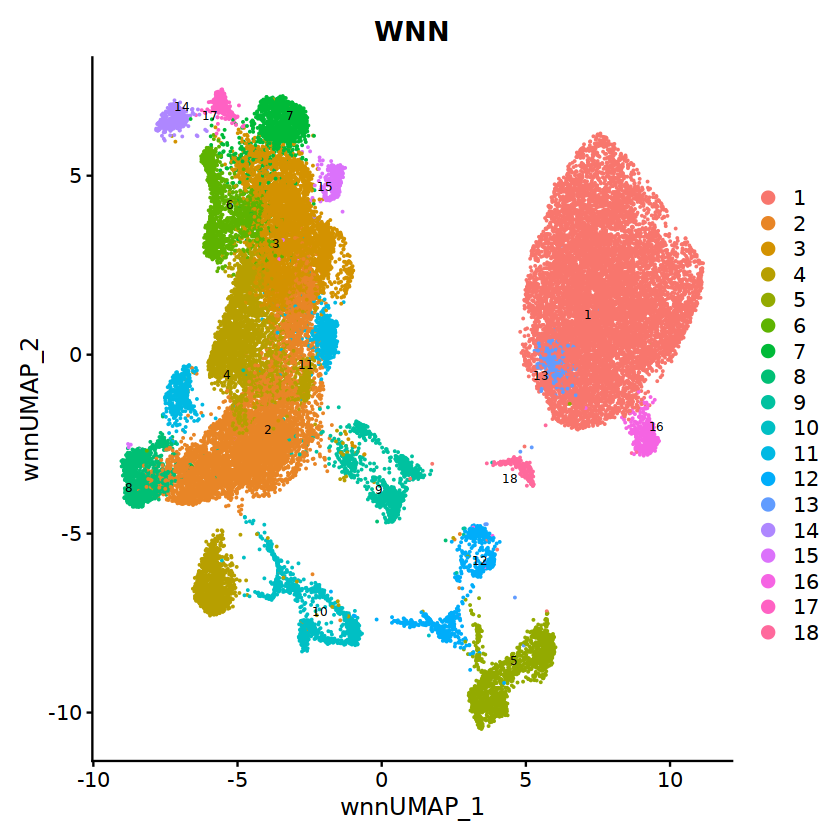

In [60]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "seurat_clusters", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3


In [62]:
setwd(path_graphs)
png(file='WNN_by_seurat_clusters_less_resolution.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## Convert to H5ad

## Reduce the Seurat object to the SCT assy (RNA normalized)

In [13]:
DefaultAssay(adata)<-'RNA_raw'
RNA_only<-DietSeurat(adata, assays = "RNA_raw")

In [14]:
RNA_only

An object of class Seurat 
36601 features across 37504 samples within 1 assay 
Active assay: RNA_raw (36601 features, 0 variable features)
 2 layers present: counts, data

In [15]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

In [16]:
dyn.load('/cm/shared/apps/hdf5/1.10.1/lib/libhdf5_hl.so.100.0.1')


In [ ]:
SaveH5Seurat(RNA_only, filename = "RNA_only.h5Seurat", overwrite=TRUE, verbose=TRUE)


Warning message:
"Overwriting previous file RNA_only.h5Seurat"
Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA_raw

Adding data for RNA_raw



In [12]:
Convert("RNA_only.h5Seurat", dest = "h5ad", overwrite=TRUE, verbose=TRUE)

Validating h5Seurat file

Warning message:
"Cannot find dataset with cell names"
Warning message:
"'assay' not set, setting to 'RNA'"


ERROR: Error: Unknown file type: h5seurat


# Read the prediction from cell typist

In [5]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

In [6]:
cell_typist<-read.csv(file="MK_diff_celltypist.csv")

In [7]:
#str(cell_typist)
str(row.names(cell_typist))
row.names(cell_typist)<-cell_typist$X


 chr [1:37504] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [8]:
str(row.names(cell_typist))

 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


In [9]:
colnames(cell_typist)

[1] "X"                                 "orig.ident"                       
 [3] "nCount_RNA"                        "nFeature_RNA"                     
 [5] "percent.mt"                        "nCount_RNA_raw"                   
 [7] "nFeature_RNA_raw"                  "nCount_ATAC"                      
 [9] "nFeature_ATAC"                     "gex_raw_reads"                    
[11] "gex_mapped_reads"                  "gex_conf_intergenic_reads"        
[13] "gex_conf_exonic_reads"             "gex_conf_intronic_reads"          
[15] "gex_conf_exonic_unique_reads"      "gex_conf_exonic_antisense_reads"  
[17] "gex_conf_exonic_dup_reads"         "gex_exonic_umis"                  
[19] "gex_conf_intronic_unique_reads"    "gex_conf_intronic_antisense_reads"
[21] "gex_conf_intronic_dup_reads"       "gex_intronic_umis"                
[23] "gex_conf_txomic_unique_reads"      "gex_umis_count"                   
[25] "gex_genes_count"                   "atac_raw_reads"                   
[27] "atac_unmapped_reads"               "atac_lowmapq"                     
[29] "atac_dup_reads"                    "atac_chimeric_reads"              
[31] "atac_mitochondrial_reads"          "atac_fragments"                   
[33] "atac_TSS_fragments"                "atac_peak_region_fragments"       
[35] "atac_peak_region_cutsites"         "TSS.enrichment"                   
[37] "TSS.percentile"                    "scDblFinder.class"                
[39] "scDblFinder.score"                 "scDblFinder.weighted"             
[41] "scDblFinder.cxds_score"            "scDblFinder.class_atac"           
[43] "scDblFinder.score_atac"            "scDblFinder.weighted_atac"        
[45] "scDblFinder.cxds_score_atac"       "No_assigned_GFPbc"                
[47] "Assigned_GFPbc"                    "Assigned_GFPgenotype"             
[49] "DBL_comb"                          "amulet_nFrags"                    
[51] "amulet_uniqFrags"                  "amulet_nAbove2"                   
[53] "amulet_total.nAbove2"              "amulet_p.value"                   
[55] "amulet_q.value"                    "doublet_amulet"                   
[57] "nCount_SCT"                        "nFeature_SCT"                     
[59] "SCT.weight"                        "ATAC.weight"                      
[61] "wsnn_res.0.2"                      "seurat_clusters"                  
[63] "doublet"                           "wsnn_res.2"                       
[65] "wsnn_res.0.5"                      "n_counts"                         
[67] "predicted_labels"                  "conf_score"

In [10]:
cell_typist_subset<-cell_typist[,c(which(colnames(cell_typist) %in% c("predicted_labels","conf_score")))]

In [11]:
str(cell_typist_subset)
str(row.names(cell_typist_subset))

'data.frame':	37504 obs. of  2 variables:
 $ predicted_labels: chr  "DC3" "DC3" "myelocyte" "myelocyte" ...
 $ conf_score      : num  1 1 1 1 1 ...
 chr [1:37504] "MCO_01326_AAACAGCCACAGCCAT-1" ...


# Add the metadata to the Seurat object

In [12]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$predicted_labels,
  col.name = 'CellTypist_label'
)

In [13]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$conf_score,
  col.name = 'CellTypist_conf_score'
)

## check

In [14]:
cell_typist_subset[c(1,100,1000,10000,30000),]

,predicted_labels,conf_score
,<chr>,<dbl>
MCO_01326_AAACAGCCACAGCCAT-1,DC3,1.0000000
MCO_01326_AAAGCGGGTTCAAGCA-1,DC3,1.0000000
MCO_01326_ACAGTATGTGAGCGAA-1,monocytoid macrophage,1.0000000
MCO_01326_GTTTAGCAGACAACGA-1,myelocyte,1.0000000
MCO_01329_CCCTCACCAGCTTACA-1,late erythroid,0.8970709


In [15]:
met<-adata[[]]

In [16]:
which(row.names(met)%in%c('MCO_01326_AAACAGCCACAGCCAT-1','MCO_01326_AAAGCGGGTTCAAGCA-1','MCO_01326_ACAGTATGTGAGCGAA-1','MCO_01326_GTTTAGCAGACAACGA-1','MCO_01329_CCCTCACCAGCTTACA-1'))

[1]     1   100  1000 10000 30000

In [17]:
adata[[]]$CellTypist_label[c(1,100,1000,10000,30000)]

[1] "DC3"                   "DC3"                   "monocytoid macrophage"
[4] "myelocyte"             "late erythroid"

In [18]:
adata

An object of class Seurat 
445320 features across 37504 samples within 4 assays 
Active assay: SCT (31512 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, RNA_raw, ATAC
 7 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, umap.wnn, harmony.rna, harmony.atac

# Plots

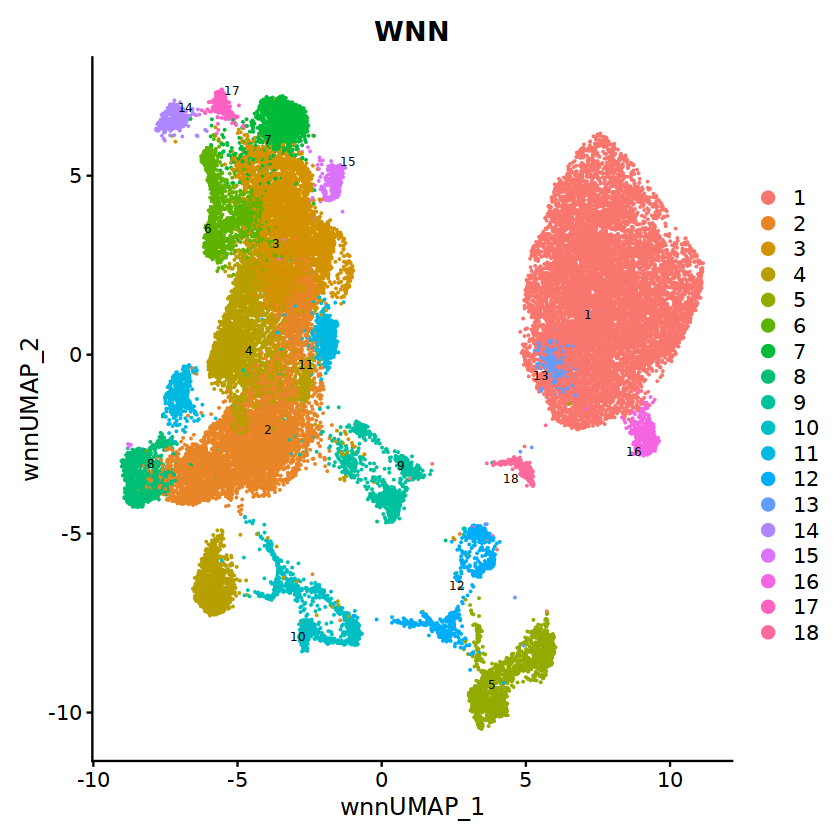

In [77]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "seurat_clusters", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3


In [78]:
summary(as.factor(adata[[]]$CellTypist_label))

adipo-CAR                basophil           CD14 monocyte 
                     11                       6                     180 
             CD4 T cell          CD56 bright NK              CD8 T cell 
                      5                       8                       2 
            chondrocyte                     CMP            DC precursor 
                      1                       1                      54 
                    DC2                     DC3         early erythroid 
                     99                    4094                    1839 
               early MK                     ELP  eo/baso/mast precursor 
                   2055                     401                      28 
             eosinophil    erythroid macrophage                     GMP 
                    741                       3                     715 
        immature B cell          late erythroid                    LMPP 
                     13                    2245                       1 
              mast cell               mature NK                     MEP 
                    111                       1                    2445 
          mid erythroid                      MK   monocytoid macrophage 
                    153                    8499                     559 
                    MOP             MPP myeloid                  muscle 
                    125                       1                       2 
       muscle stem cell               myelocyte           myofibroblast 
                      4                    5686                       9 
           naive B cell              neutrophil               NK T cell 
                     51                     333                      25 
   osteoblast precursor osteochondral precursor              osteoclast 
                    410                     113                      38 
                    pDC        pre B progenitor    pre pro B progenitor 
                     32                      81                    1885 
       pro B progenitor             promonocyte            promyelocyte 
                    251                      92                      42 
          schwann cells           sinusoidal EC      stromal macrophage 
                   2494                    1076                      10 
                    tDC                  tip EC 
                      6                     468

In [19]:
met.dt<-data.table(met, key="CellTypist_label")

In [20]:
Freq.table<-as.data.frame(met.dt[,.(.N),by=key(met.dt)], stringsAsFactors=F)

In [21]:
str(Freq.table)

'data.frame':	50 obs. of  2 variables:
 $ CellTypist_label: chr  "CD14 monocyte" "CD4 T cell" "CD56 bright NK" "CD8 T cell" ...
 $ N               : int  180 5 8 2 1 54 99 4094 401 715 ...


In [22]:
Freq.table_FILT<-Freq.table[which(Freq.table$N < 500),]

In [23]:
str(Freq.table_FILT)

'data.frame':	37 obs. of  2 variables:
 $ CellTypist_label: chr  "CD14 monocyte" "CD4 T cell" "CD56 bright NK" "CD8 T cell" ...
 $ N               : int  180 5 8 2 1 54 99 401 1 125 ...


In [24]:
adata$CellTypist_label_filtered<-adata$CellTypist_label

In [25]:
adata$CellTypist_label_filtered[which(adata$CellTypist_label_filtered%in%Freq.table_FILT$CellTypist_label)]<-NA

In [26]:
summary(as.factor(adata[[]]$CellTypist_label_filtered))

DC3       early erythroid              early MK 
                 4094                  1839                  2055 
           eosinophil                   GMP        late erythroid 
                  741                   715                  2245 
                  MEP                    MK monocytoid macrophage 
                 2445                  8499                   559 
            myelocyte  pre pro B progenitor         schwann cells 
                 5686                  1885                  2494 
        sinusoidal EC                  NA's 
                 1076                  3171

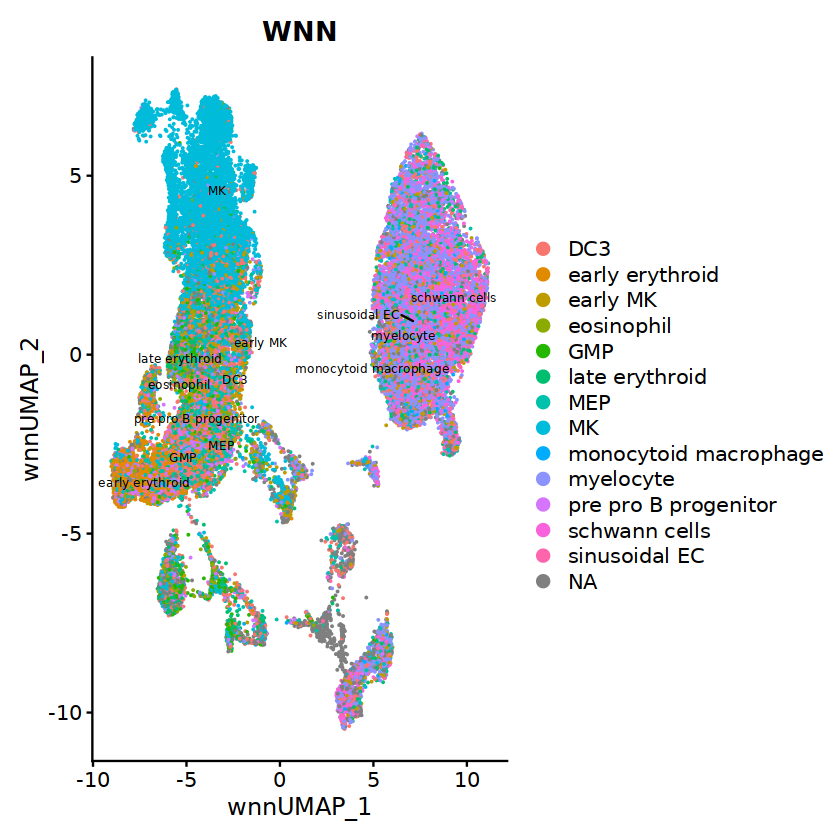

In [87]:
p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "CellTypist_label_filtered", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
p3

# Graphs

In [27]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/graphs_FINAL_HARMONY"

In [89]:
## Graph WNN by CellTypist_label_filtered

p3 <- DimPlot(adata, reduction = "umap.wnn", group.by = "CellTypist_label_filtered", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

setwd(path_graphs)
png(file='WNN_by_CellTypist_label_filtered.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

In [90]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "wsnn_res.1"                        "wsnn_res.0.25"                    
[67] "CellTypist_label"                  "CellTypist_conf_score"            
[69] "CellTypist_label_filtered"

png 
  2

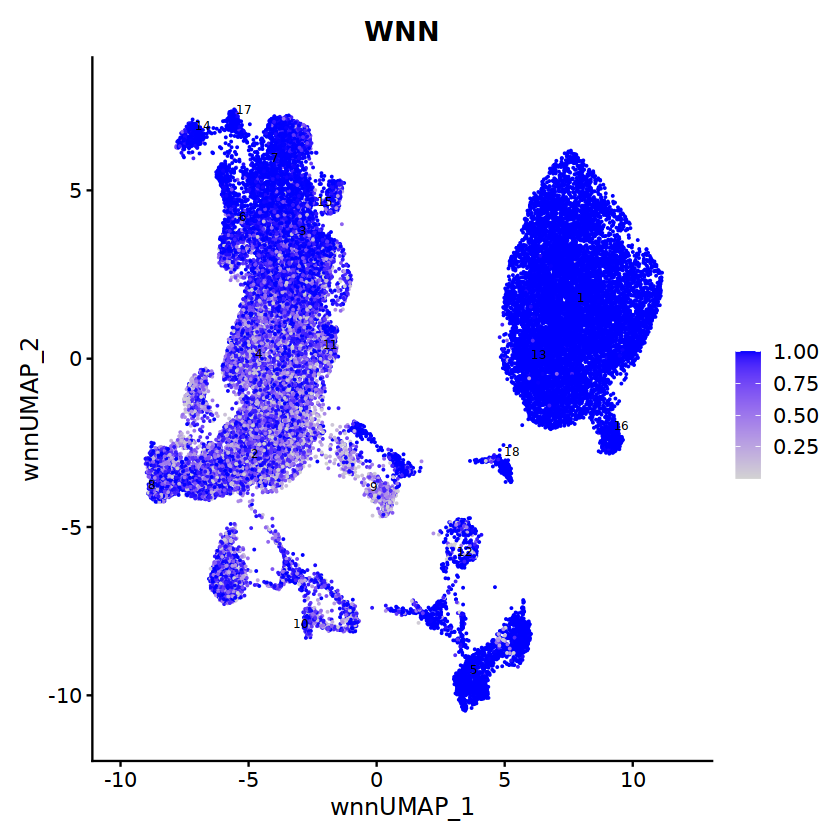

In [91]:
## Graph WNN by CellTypist_conf_score

p3 <- FeaturePlot(adata, reduction = "umap.wnn", 
              features = "CellTypist_conf_score", 
              label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

p3

setwd(path_graphs)
png(file='WNN_by_CellTypist_conf_score_filtered.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

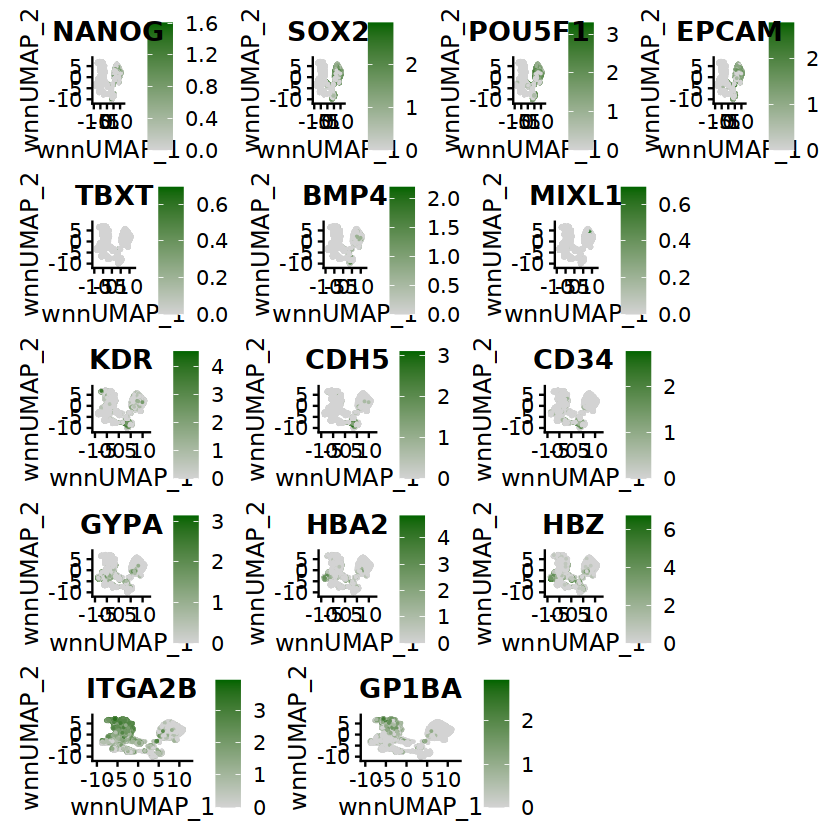

In [29]:
## Graph WNN by marker genes

DefaultAssay(adata) <- 'SCT'


p5 <- FeaturePlot(adata, features = c("NANOG",'SOX2','POU5F1','EPCAM'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)

p5_A <- FeaturePlot(adata, features = c("TBXT",'BMP4','MIXL1'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)
p5_B <- FeaturePlot(adata, features = c("KDR",'CDH5','CD34'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)
p5_1 <- FeaturePlot(adata, features = c('GYPA','HBA2','HBZ'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)
p5_2 <- FeaturePlot(adata, features = c('ITGA2B','GP1BA'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

p5 / p5_A / p5_B / p5_1 / p5_2

setwd(path_graphs)
png(file='WNN_marker_genes_2.png', width =1000, height = 1000)
p5 / p5_A / p5_B / p5_1 / p5_2
dev.off()


In [93]:
## Graph WNN by marker genes

DefaultAssay(adata) <- 'SCT'


p5 <- FeaturePlot(adata, features = c("NANOG",'SOX4'),
                  reduction = 'umap.wnn', 
                  cols = c("lightgrey","darkgreen"), ncol = 4)
p5_1 <- FeaturePlot(adata, features = c('GYPA','HBA2','HBZ'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)
p5_2 <- FeaturePlot(adata, features = c('ITGA2B','GP1BA'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

p5_3 <- FeaturePlot(adata, features = c('KIF15','STIL','ANAPC7'),
                    reduction = 'umap.wnn', 
                    cols = c("lightgrey","darkgreen"), ncol = 4)

setwd(path_graphs)
png(file='WNN_marker_genes.png', width =1000, height = 800)
p5 / p5_1 /p5_2/p5_3
dev.off()

png 
  2

In [94]:
adata_CT<-subset(adata, CellTypist_label_filtered != "NA")

Warning message:
"Removing 3171 cells missing data for vars requested"


png 
  2

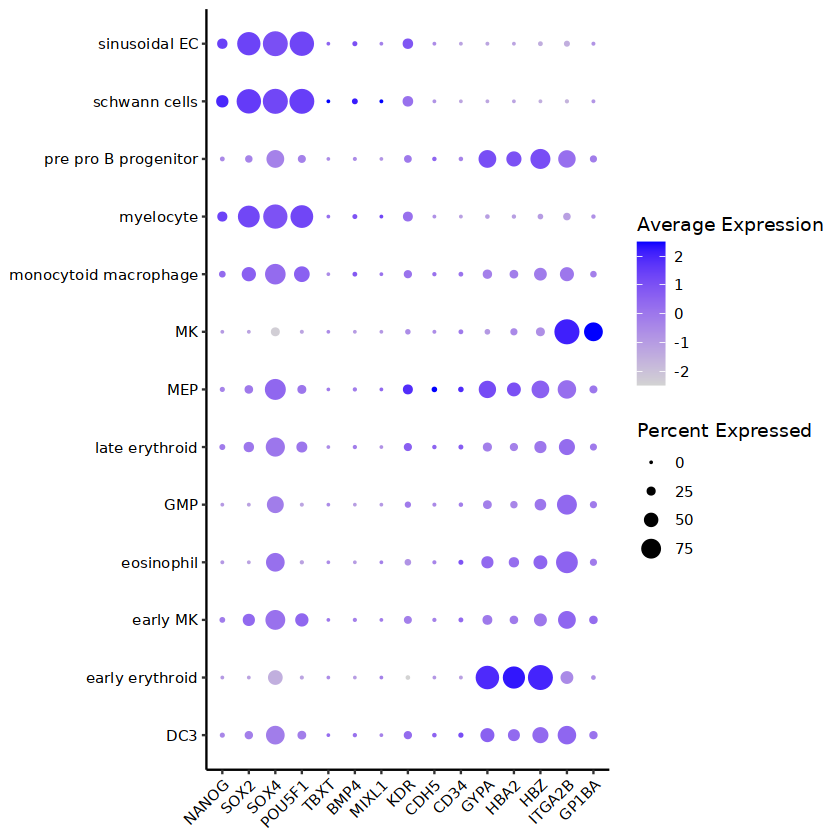

In [99]:
dotplot3<-DotPlot(
  adata_CT,
  features=c("NANOG",'SOX2','SOX4','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="CellTypist_label_filtered")+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_blank(),
          axis.title.x=element_blank(),
          axis.text.y=element_text(color="black", family="sans"),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans"))
dotplot3

setwd(path_graphs)
png(file='Dotplot_marker_genes_by_CellTypist_label_filtered.png', width =1000, height = 800)
dotplot3
dev.off()

png 
  2

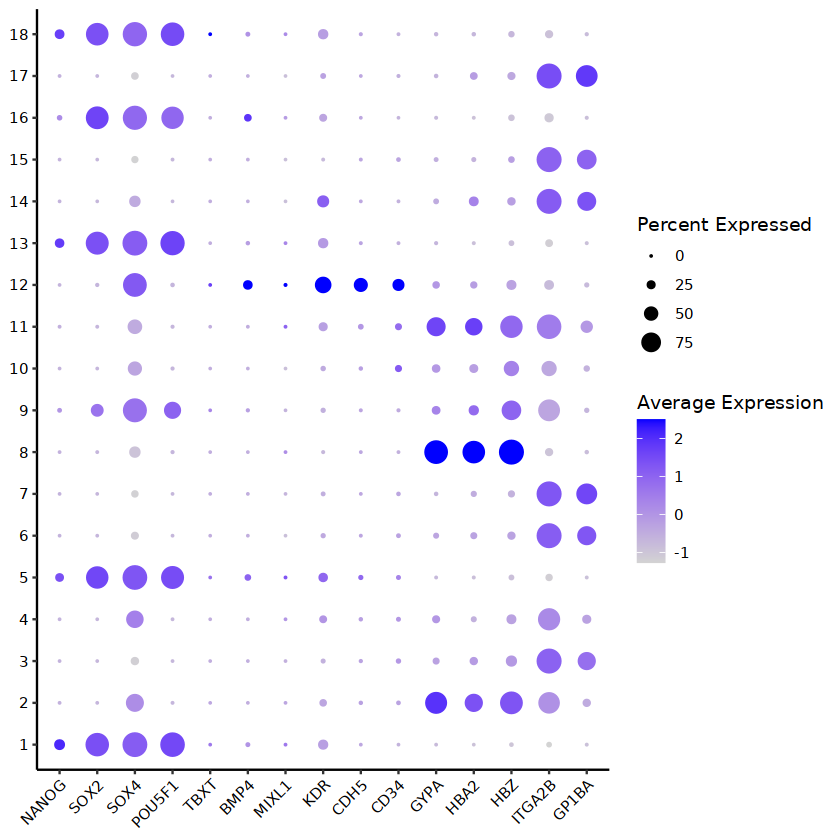

In [100]:
dotplot3<-DotPlot(
  adata,
  features=c("NANOG",'SOX2','SOX4','POU5F1',"TBXT",'BMP4','MIXL1',"KDR",'CDH5','CD34','GYPA','HBA2','HBZ','ITGA2B','GP1BA'),
  assay = "SCT",
    group.by="seurat_clusters")+
 theme_classic()+
    theme(axis.title=element_blank(),
          axis.title.y=element_blank(),
          axis.title.x=element_blank(),
          axis.text.y=element_text(color="black", family="sans"),
          axis.text.x=element_text(angle=45,vjust=1,hjust=1, color="black", family="sans"))
dotplot3

setwd(path_graphs)
png(file='Dotplot_marker_genes_by_seurat_clusters.png', width =1000, height = 800)
dotplot3
dev.off()

In [89]:
met<-adata[[]]
colnames(met)

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "gex_raw_reads"                     "gex_mapped_reads"                 
[11] "gex_conf_intergenic_reads"         "gex_conf_exonic_reads"            
[13] "gex_conf_intronic_reads"           "gex_conf_exonic_unique_reads"     
[15] "gex_conf_exonic_antisense_reads"   "gex_conf_exonic_dup_reads"        
[17] "gex_exonic_umis"                   "gex_conf_intronic_unique_reads"   
[19] "gex_conf_intronic_antisense_reads" "gex_conf_intronic_dup_reads"      
[21] "gex_intronic_umis"                 "gex_conf_txomic_unique_reads"     
[23] "gex_umis_count"                    "gex_genes_count"                  
[25] "atac_raw_reads"                    "atac_unmapped_reads"              
[27] "atac_lowmapq"                      "atac_dup_reads"                   
[29] "atac_chimeric_reads"               "atac_mitochondrial_reads"         
[31] "atac_fragments"                    "atac_TSS_fragments"               
[33] "atac_peak_region_fragments"        "atac_peak_region_cutsites"        
[35] "TSS.enrichment"                    "TSS.percentile"                   
[37] "scDblFinder.class"                 "scDblFinder.score"                
[39] "scDblFinder.weighted"              "scDblFinder.cxds_score"           
[41] "scDblFinder.class_atac"            "scDblFinder.score_atac"           
[43] "scDblFinder.weighted_atac"         "scDblFinder.cxds_score_atac"      
[45] "No_assigned_GFPbc"                 "Assigned_GFPbc"                   
[47] "Assigned_GFPgenotype"              "DBL_comb"                         
[49] "amulet_nFrags"                     "amulet_uniqFrags"                 
[51] "amulet_nAbove2"                    "amulet_total.nAbove2"             
[53] "amulet_p.value"                    "amulet_q.value"                   
[55] "doublet_amulet"                    "nCount_SCT"                       
[57] "nFeature_SCT"                      "SCT.weight"                       
[59] "ATAC.weight"                       "wsnn_res.0.2"                     
[61] "seurat_clusters"                   "doublet"                          
[63] "wsnn_res.2"                        "wsnn_res.0.5"                     
[65] "CellTypist_label"                  "CellTypist_label_filtered"

In [91]:
met.dt<-data.table(met, key=c("Assigned_GFPbc","CellTypist_label_filtered"))

In [92]:
Freq.table<-as.data.frame(met.dt[,.(.N),by=key(met.dt)], stringsAsFactors=F)

In [95]:
str(Freq.table)

'data.frame':	184 obs. of  3 variables:
 $ Assigned_GFPbc           : Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: NA NA NA NA NA NA NA NA NA NA ...
 $ CellTypist_label_filtered: chr  NA "DC3" "GMP" "MEP" ...
 $ N                        : int  2664 3564 534 2176 6547 1688 1627 589 1839 480 ...


In [96]:
Freq.table[which(Freq.table$CellTypist_label_filtered == 'MK'),]

,Assigned_GFPbc,CellTypist_label_filtered,N
,<ord>,<chr>,<int>
5,NA,MK,6547
19,chrGFP_WTA,MK,8
31,chrGFP_WTB,MK,17
44,chrGFP_WTC,MK,35
58,chrGFP_rs1,MK,165
72,chrGFP_rs2,MK,113
86,chrGFP_rs3,MK,1359
100,chrGFP_R882H1,MK,35
113,chrGFP_R882H2,MK,7


In [97]:
Freq.table[which(Freq.table$CellTypist_label_filtered == 'early erythroid'),]

,Assigned_GFPbc,CellTypist_label_filtered,N
,<ord>,<chr>,<int>
7,NA,early erythroid,1627
21,chrGFP_WTA,early erythroid,4
33,chrGFP_WTB,early erythroid,2
46,chrGFP_WTC,early erythroid,5
60,chrGFP_rs1,early erythroid,13
74,chrGFP_rs2,early erythroid,16
88,chrGFP_rs3,early erythroid,118
102,chrGFP_R882H1,early erythroid,4
126,chrGFP_R882H3,early erythroid,1


In [98]:
Freq.table[which(Freq.table$CellTypist_label_filtered == 'MEP'),]

,Assigned_GFPbc,CellTypist_label_filtered,N
,<ord>,<chr>,<int>
4,NA,MEP,2176
18,chrGFP_WTA,MEP,3
30,chrGFP_WTB,MEP,2
43,chrGFP_WTC,MEP,8
57,chrGFP_rs1,MEP,11
71,chrGFP_rs2,MEP,13
85,chrGFP_rs3,MEP,111
99,chrGFP_R882H1,MEP,32
112,chrGFP_R882H2,MEP,2


In [99]:
Freq.table[which(Freq.table$CellTypist_label_filtered == 'late erythroid'),]

,Assigned_GFPbc,CellTypist_label_filtered,N
,<ord>,<chr>,<int>
9,NA,late erythroid,1839
22,chrGFP_WTA,late erythroid,1
34,chrGFP_WTB,late erythroid,8
48,chrGFP_WTC,late erythroid,4
62,chrGFP_rs1,late erythroid,21
76,chrGFP_rs2,late erythroid,20
90,chrGFP_rs3,late erythroid,192
104,chrGFP_R882H1,late erythroid,39
115,chrGFP_R882H2,late erythroid,5


In [101]:
met.dt<-data.table(met, key=c("Assigned_GFPbc","seurat_clusters"))

In [103]:
Freq.table<-as.data.frame(met.dt[,.(.N),by=key(met.dt)], stringsAsFactors=F)

In [104]:
str(Freq.table)

'data.frame':	217 obs. of  3 variables:
 $ Assigned_GFPbc : Ord.factor w/ 13 levels "chrGFP_WTA"<"chrGFP_WTB"<..: NA NA NA NA NA NA NA NA NA NA ...
 $ seurat_clusters: Factor w/ 18 levels "1","2","3","4",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ N              : int  9272 5630 3566 3168 1266 1060 1033 1183 940 840 ...


In [107]:
Freq.table[which(Freq.table$seurat_clusters == '12'),]

,Assigned_GFPbc,seurat_clusters,N
,<ord>,<fct>,<int>
12,NA,12,775
41,chrGFP_WTB,12,3
58,chrGFP_WTC,12,3
75,chrGFP_rs1,12,2
91,chrGFP_rs2,12,1
108,chrGFP_rs3,12,23
125,chrGFP_R882H1,12,6
139,chrGFP_R882H2,12,2
152,chrGFP_R882H3,12,5


# SAVE

In [ ]:
setwd("/group/soranzo/manuel.tardaguila/2025_hESC_MK_multiome/processing_outputs/")

adata<-saveRDS(adata,file="merged_unprocessed_db_filt_clustered_minus_26_MACS2_peaks_HARMONY_clustered_withCellTypBMA.rds")